In [1]:
import os
import requests
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Font settings
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


In [2]:
#let's download and import the feature table directly from the FBMN job in GNPS2
task_id = '345d29336f5a4a70b2eeaefae56f8592'
response = requests.get(f'https://gnps2.org/result?task={task_id}&viewname=quantificationdownload&resultdisplay_type=task')
directory_path = '/Users/helenarusso/Documents/Pesquisa/UCSD Post-doc/Carnitines/2025/Examples/temp'

#import the metadata
metadata = pd.read_csv('/Users/helenarusso/Documents/Pesquisa/UCSD Post-doc/Carnitines/2025/Examples/Patterson_circadian_rythm/metadata_all_samples.txt', sep='\t') #not publicly available

with open(directory_path + task_id + '.csv', 'wb') as f:
    f.write(response.content)
    print(f"File saved at {directory_path}")
    
ftable = pd.read_csv(os.path.join(directory_path + task_id + '.csv'), sep=',')
#just keep the column relative to the samples and feature ids.
ftable = ftable[[col for col in ftable.columns if col.endswith('Peak area') or col == 'row ID']]


File saved at /Users/helenarusso/Documents/Pesquisa/UCSD Post-doc/Carnitines/2025/Examples/temp


In [3]:
#import library matches to the carnitines massQL library
library_matches = pd.read_csv('/Users/helenarusso/Documents/Pesquisa/UCSD Post-doc/Carnitines/2025/Examples/Patterson_circadian_rythm/library_matches_postMN_MassQL_85at5.tsv', sep='\t')

#filter first for the annotations that pass the carnitine query
library_matches = library_matches[library_matches['query_validation'] == 'carnitines']

#create another column specifically for the carnitines with putative explanation:
library_matches = library_matches[library_matches['Compound_Name'].str.contains('putative')]

library_matches['Compound_Name_simplified'] = library_matches['Compound_Name'].str.split('explanation: ').str[-1]
library_matches['Compound_Name_simplified'] = library_matches['Compound_Name_simplified'].str.replace(')', '', regex=True)
library_matches['Compound_Name_simplified'] = library_matches['Compound_Name_simplified'].str.replace(', O', ';O', regex=True)


In [4]:
# keep only matches to the carnitines with putative annotation
ftable_filtered = ftable[ftable['row ID'].isin(library_matches['#Scan#'].unique())]

#rename header to #Scan#
ftable_filtered = ftable_filtered.rename(columns={'row ID': '#Scan#'})

#merge annotation
ftable_filtered = pd.merge(ftable_filtered, library_matches[['#Scan#', 'Compound_Name_simplified']], 
                           on='#Scan#', how='left')

#create column scan_compound
ftable_filtered['scan_compound'] = ftable_filtered['#Scan#'].astype(str) + "_" + ftable_filtered['Compound_Name_simplified'].astype(str)

#put as first column
ftable_filtered = ftable_filtered[[ftable_filtered.columns[-1]] + list(ftable_filtered.columns[:-1])]

#drop Scan and compound_name_simplified columns
ftable_filtered = ftable_filtered.drop(columns=['#Scan#', 'Compound_Name_simplified'])

#transpose column
ftable_T = ftable_filtered.T
ftable_T.columns = ftable_T.iloc[0]   # take first row as header
ftable_T = ftable_T.drop(ftable_T.index[0]).reset_index()  # drop that row

#rename column and remove ' Peak area'
ftable_T = ftable_T.rename(columns={'index': 'filename'})
ftable_T['filename'] = ftable_T['filename'].str.replace(' Peak area', '', regex=True)


In [5]:
#merge with metadata
ftable_merged = pd.merge(ftable_T, metadata, on='filename', how='left')

#keep only samples
ftable_merged = ftable_merged[ftable_merged['sample_type'] == 'sample']

#concatenate tissue and time
ftable_merged['tissue_time'] = ftable_merged['tissue'] + "_" + ftable_merged['ZT'].astype(str)

#drop columns
ftable_merged = ftable_merged.drop(columns=['ZT', 'sample_type', 'tissue'])

#put as first column
ftable_merged = ftable_merged[[ftable_merged.columns[-1]] + list(ftable_merged.columns[:-1])]

#use groupby to have the average of compound in each time point for each organ
ftable_merged = ftable_merged.groupby('tissue_time').median().reset_index()

#create the tissue column and time
ftable_merged['tissue'] = ftable_merged['tissue_time'].str.split('_').str[0]
ftable_merged['time'] = ftable_merged['tissue_time'].str.split('_').str[1]

#remove T from time
ftable_merged['time'] = ftable_merged['time'].str.replace('T', '', regex=True)


# Convert to ordered categorical
time_order = ['0', '4', '8', '12', '16', '20']
ftable_merged['time'] = pd.Categorical(ftable_merged['time'], categories=time_order, ordered=True)

#sort in the desired time order
ftable_merged = ftable_merged.sort_values(by=['tissue', 'time']).reset_index(drop=True)

#put as first column twice
ftable_merged = ftable_merged[[ftable_merged.columns[-1]] + list(ftable_merged.columns[:-1])]
ftable_merged = ftable_merged[[ftable_merged.columns[-1]] + list(ftable_merged.columns[:-1])]

df = ftable_merged.copy()

/Users/helenarusso/opt/miniconda3/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3331: FutureWarning: Dropping invalid columns in DataFrameGroupBy.median is deprecated. In a future version, a TypeError will be raised. Before calling .median, select only columns which should be valid for the function.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [6]:
# melt the dataframe for long format
df_melted = df.melt(
    id_vars=["tissue", "time"],     # keep these fixed
    var_name="Metabolite",          # column with metabolite names
    value_name="Abundance"          # column with abundance values
)

df_melted = df_melted[df_melted['Metabolite'] != 'tissue_time']
df_melted['Metabolite'] = df_melted['Metabolite'].str.replace(', ', ';', regex=True)

#create a column with the number of carbons of the annotation
df_melted['carbons'] = df_melted['Metabolite'].str.split('CAR ').str[-1]
df_melted['carbons'] = df_melted['carbons'].str.split(':').str[0]
df_melted['carbons'] = df_melted['carbons'].str.replace('C', '', regex=True)
df_melted['carbons'] = df_melted['carbons'].astype(int)

#column for unsaturations
df_melted['unsaturations'] = df_melted['Metabolite'].str.split('CAR ').str[-1]
df_melted['unsaturations'] = df_melted['unsaturations'].str.split(':').str[1]
df_melted['unsaturations'] = df_melted['unsaturations'].str.split(';').str[0]
df_melted['unsaturations'] = df_melted['unsaturations'].astype(int)

# column for hydroxy groups
df_melted['hydroxy'] = df_melted['Metabolite'].str.split(';O').str[-1]
df_melted.loc[df_melted["hydroxy"].str.contains("CAR", na=False), "hydroxy"] = 0
df_melted["hydroxy"] = df_melted["hydroxy"].replace("", pd.NA).fillna(1)
df_melted['hydroxy'] = df_melted['hydroxy'].astype(int)

# and include the precmz from the library searches
library_matches['Metabolite'] = library_matches['#Scan#'].astype(str) + "_" + library_matches['Compound_Name_simplified']
library_matches['Metabolite'] = library_matches['Metabolite'].str.replace(', ', ';', regex=True)


df_melted = pd.merge(df_melted, library_matches[['Metabolite', 'SpecMZ']], on='Metabolite',
                    how = 'left')

In [7]:
# and let's also create a classification for chain length and even/odd number of carbons
df_melted['carbons'] = df_melted['Metabolite'].str.split(' ').str[-1]
df_melted['carbons'] = df_melted['carbons'].str.split(':').str[0]
df_melted['carbons'] = df_melted['carbons'].str.replace('C', '', regex=True)

def classify_length(c):
    if 2 <= c <= 6:
        return "short"
    elif 7 <= c <= 12:
        return "medium"
    elif 13 <= c <= 21:
        return "long"
    elif 22 <= c <= 30:
        return "very long"
    else:
        return "unknown"

# make sure carbons is numeric
df_melted['carbons'] = df_melted['carbons'].astype(int)

df_melted['carbons_length'] = df_melted['carbons'].apply(classify_length)
df_melted['even_odd'] = df_melted['carbons'].apply(lambda x: "even" if x % 2 == 0 else "odd")

In [8]:
hydroxy_colors = {
    0: '#82C180',
    1: '#FABF87', 
    2: '#E71880',
    3: '#666666'
}

carbons_length_colors = {
    'short': '#F9ED9B',
    'medium': '#9ACFB7', 
    'long': '#1F81B9',
    'very long': '#212950'
}

unsaturations_colors = {
    0: '#2078B5',
    1: '#F07E21', 
    2: '#D72829',
    3: '#8D574C',
    4: '#D37AB0',
    5: '#BDBD21', 
    6: '#2BB8CB'
}

even_odd_colors = {
    'even': '#8C389B',
    'odd':  '#E28DB9'
}

# Stacked bar plots

In [9]:
def create_stacked_barplots(df_melted, variable='hydroxy', tissue_order=None, colors=None, category_order=None):
    if tissue_order is None:
        tissue_order = [
            'StomachConts', 'Stomach',
            'DuodenumConts', 'Duodenum',
            'JejunumConts', 'Jejunum',
            'IlealCont', 'Ileum',
            'CecalConts', 'Cecum',
            'ColonConts', 'Colon',
            'Feces',
            'Blood', 'Urine', 'Liver',
            'Kidney', 'Lung', 'Spleen', 'Heart',
            'Skin', 'Eye', 'Brain'
        ]

    available_tissues = set(df_melted['tissue'].unique())
    tissues = [t for t in tissue_order if t in available_tissues]

    if not tissues:
        raise ValueError('No matching tissues found in the input dataframe.')

    n_rows = len(tissues)

    fig, axes = plt.subplots(n_rows, 1, figsize=(4.5, 2.5 * n_rows), squeeze=False)
    axes = axes.flatten()

    for i, (ax, tissue) in enumerate(zip(axes, tissues)):
        tissue_data = df_melted[df_melted['tissue'] == tissue]

        grouped = tissue_data.groupby(['time', variable])['Abundance'].sum().reset_index()
        pivot_absolute = grouped.pivot(index='time', columns=variable, values='Abundance').fillna(0)

        if category_order is not None:
            ordered_existing = [c for c in category_order if c in pivot_absolute.columns]
            remaining = [c for c in pivot_absolute.columns if c not in ordered_existing]
            pivot_absolute = pivot_absolute[ordered_existing + remaining]

        # Build a color list in the same order as the pivoted columns
        if colors is not None:
            bar_colors = [colors.get(col, '#CCCCCC') for col in pivot_absolute.columns]
        else:
            bar_colors = None

        pivot_absolute.plot(
            kind='bar',
            stacked=True,
            ax=ax,
            color=bar_colors,
            edgecolor='black',
            linewidth=0.5,
            width=0.75
        )

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_color('black')

        is_bottom = i == n_rows - 1
        ax.tick_params(axis='both', which='major', color='black', left=True, top=False, right=False)
        ax.tick_params(axis='x', rotation=0, labelbottom=is_bottom, bottom=is_bottom)

        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

        ax.set_xlabel('Time' if is_bottom else '')
        ax.set_ylabel(f'Abundance ({tissue})')
        ax.legend(title=variable, bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(False)

    plt.tight_layout(pad=0, h_pad=0)
    plt.show()


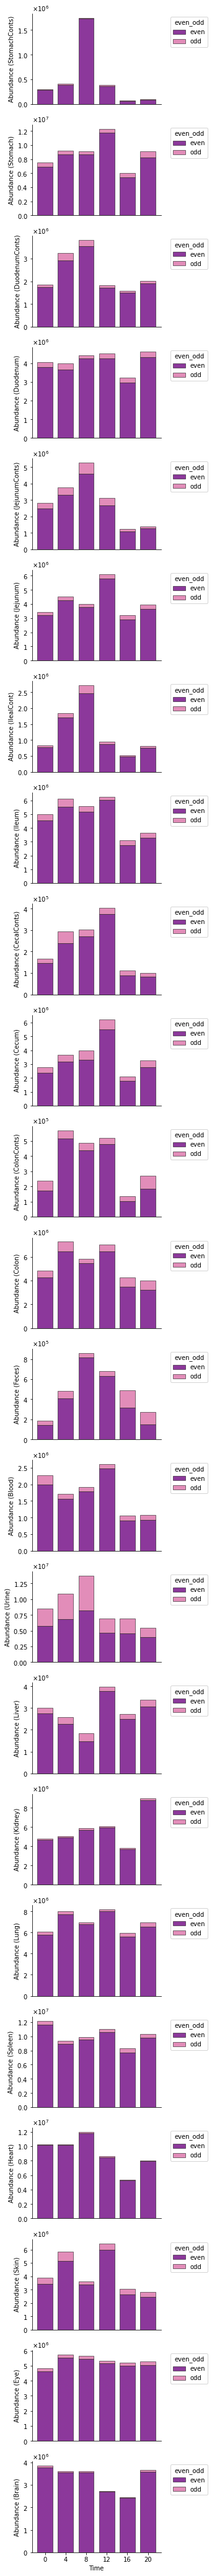

In [10]:
create_stacked_barplots(df_melted, variable='even_odd', colors=even_odd_colors)


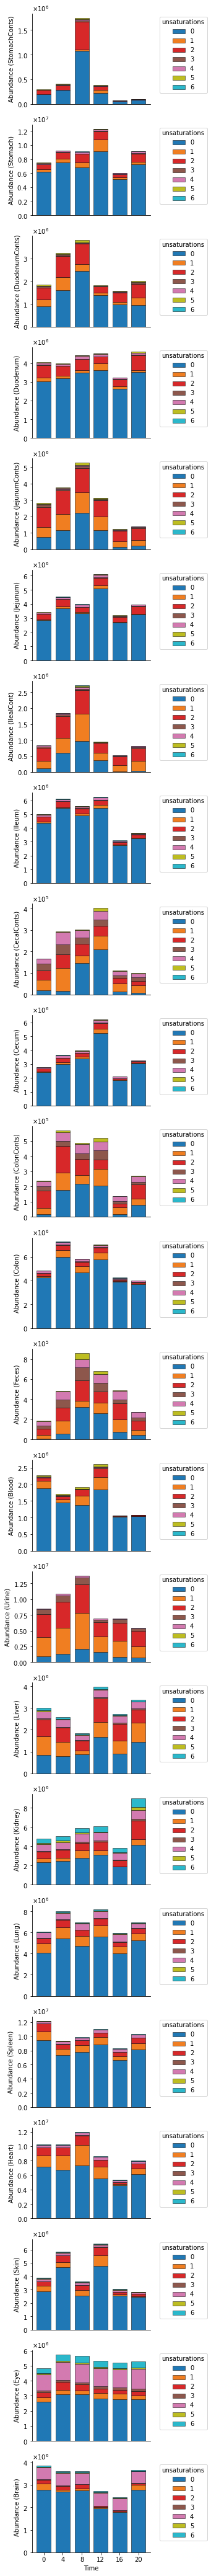

In [11]:
create_stacked_barplots(df_melted, variable='unsaturations', colors=unsaturations_colors)


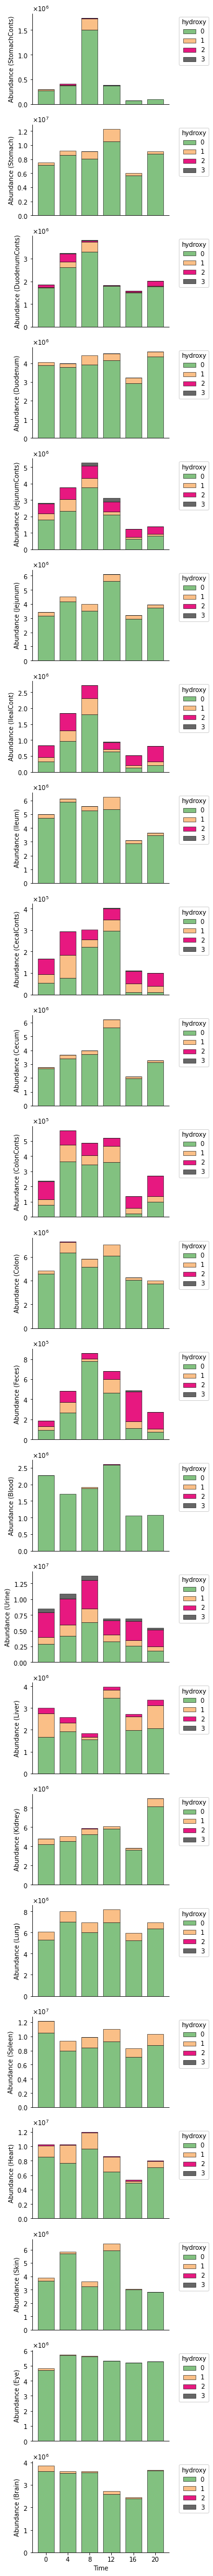

In [12]:
create_stacked_barplots(df_melted, variable='hydroxy', colors=hydroxy_colors)


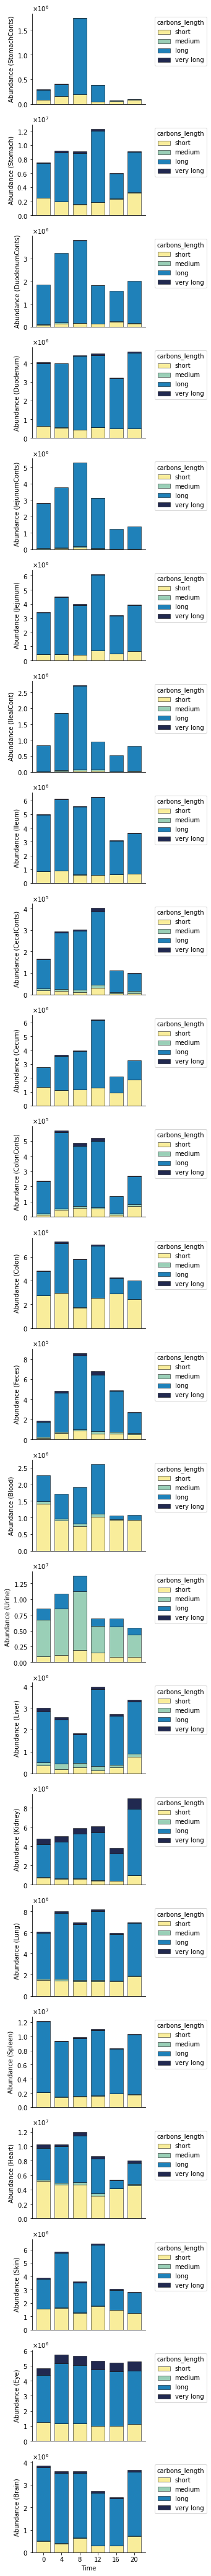

In [13]:
create_stacked_barplots(
    df_melted,
    variable='carbons_length',
    colors=carbons_length_colors,
    category_order=['short', 'medium', 'long', 'very long']
 )
